# 8 Student–Teacher Anomaly Detection

## Approach

Student–Teacher (S–T) anomaly detection uses two networks with identical architecture:
- **Teacher**: frozen pretrained ResNet-18 — a fixed feature extractor
- **Student**: same architecture, trained to mimic the teacher on **normal patches only**

On normal patches the student learns to replicate the teacher's features closely.  
On anomalous patches (unseen during training), the student fails to replicate the teacher → high prediction error → high anomaly score.

**Anomaly score** = mean squared difference between teacher and student feature maps.

## Why S–T over AE?
- AE reconstructs in pixel space — blurry reconstructions wash out thin cracks
- S–T operates in **feature space** — richer, more discriminative representations
- Teacher features are fixed and informative; student divergence is a clean anomaly signal
    - It keeps spatial information, so a small crack does not get averaged away as easily as in image-level SVDD.
    - It does not reconstruct pixels, so it avoids the AE failure mode where the model learns to reconstruct cracks too.
    - It uses a teacher target, which stabilises training better than one-class collapse-based objectives like SVDD.

## Feature Pyramid Loss (Multi-Scale)
Cracks vary in scale — hairline to wide. We extract features at **two ResNet levels**:
- `layer2` (stride 8, fine-grained texture)
- `layer3` (stride 16, higher-level structure)

The total loss is the sum of distillation losses at both scales, forcing the student  
to match the teacher across multiple receptive fields.

| # | Variant | Key addition |
|---|---------|-------------|
| A | S–T Baseline | Single-scale (layer3 only) |
| B | S–T + FPN | Multi-scale (layer2 + layer3) |

In [ ]:
import sys, os
sys.path.insert(0, os.path.abspath('.'))

import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import torchvision.models as tvm
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader
from sklearn.metrics import roc_auc_score

from src.dataset import CrackDataset, load_splits
from src.train_utils import calibrate_threshold, compute_metrics
from src.viz_utils import plot_score_histogram, plot_roc_curve, plot_confusion_matrix


SPLITS_DIR  = 'splits'
BATCH_SIZE  = 32
NUM_EPOCHS  = 30
PATIENCE    = 5
LR          = 1e-4
WEIGHT_DECAY = 1e-4
SEED        = 42

torch.manual_seed(SEED)
np.random.seed(SEED)
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {DEVICE}')

Device: cuda


In [ ]:

train_records, val_records, test_records = load_splits(SPLITS_DIR)

train_normal = [r for r in train_records if r['label'] == 0]

train_ds = CrackDataset(train_normal, preprocessing='none', augment=True)
val_ds   = CrackDataset(val_records,  preprocessing='none', augment=False)
test_ds  = CrackDataset(test_records, preprocessing='none', augment=False)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,  num_workers=0)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False, num_workers=0)
test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

val_labels  = np.array([r['label'] for r in val_records])
test_labels = np.array([r['label'] for r in test_records])

print(f'Train normal: {len(train_ds):,}  |  Val: {len(val_ds):,}  |  Test: {len(test_ds):,}')

Train normal: 15,207  |  Val: 3,650  |  Test: 3,651


## Model Definition

The teacher is initialized with **pretrained ImageNet weights and fully frozen**.  
The student is initialized from **random weights** — it must actively learn to mimic  
the teacher on normal patches from scratch. This maximizes the divergence gap on  
anomalous patches that the student has never seen.

Using pretrained weights for the student (as done initially) was the core bug:  
the student already knows how to mimic the teacher from day one, so the loss  
starts near-zero and the model never develops a meaningful anomaly signal.

We extract intermediate feature maps using forward hooks.

In [ ]:
class FeatureExtractor(nn.Module):

    def __init__(self, layers: list, pretrained: bool = True, frozen: bool = False):
        super().__init__()
        resnet = tvm.resnet18(weights=tvm.ResNet18_Weights.DEFAULT if pretrained else None)
        # Remove final avgpool + fc — we only need feature maps
        self.backbone = nn.Sequential(
            resnet.conv1, resnet.bn1, resnet.relu, resnet.maxpool,
            resnet.layer1, resnet.layer2, resnet.layer3, resnet.layer4
        )
        # Name the sub-modules so we can register hooks by name
        self.layer_map = {
            'layer1': resnet.layer1,
            'layer2': resnet.layer2,
            'layer3': resnet.layer3,
            'layer4': resnet.layer4,
        }
        self.target_layers = layers
        self._features = {}
        self._hooks = []
        self._register_hooks()

        if frozen:
            for p in self.parameters():
                p.requires_grad = False

    def _register_hooks(self):
        for name in self.target_layers:
            module = self.layer_map[name]
            hook = module.register_forward_hook(
                lambda m, inp, out, n=name: self._features.__setitem__(n, out)
            )
            self._hooks.append(hook)

    def forward(self, x):
        self._features.clear()
        self.backbone(x)
        return {k: self._features[k] for k in self.target_layers}

    def remove_hooks(self):
        for h in self._hooks:
            h.remove()


# Sanity check
dummy = torch.randn(2, 3, 256, 256)
te = FeatureExtractor(['layer2', 'layer3'], pretrained=True, frozen=True)
feats = te(dummy)
for k, v in feats.items():
    print(f'  {k}: {tuple(v.shape)}')
te.remove_hooks()
print('FeatureExtractor OK')

  layer2: (2, 128, 32, 32)
  layer3: (2, 256, 16, 16)
FeatureExtractor OK


## Shared Training Loop

In [ ]:
def anomaly_scores(teacher, student, loader, device, layer_weights=None, normalize=False):
    teacher.eval()
    student.eval()
    scores = []
    with torch.no_grad():
        for x, _ in loader:
            x = x.to(device)
            t_feats = teacher(x)
            s_feats = student(x)
            batch_scores = torch.zeros(x.size(0), device=device)
            for key in t_feats:
                w = layer_weights[key] if layer_weights else 1.0
                diff = (t_feats[key] - s_feats[key]) ** 2  # (B, C, H, W)
                mse  = diff.mean(dim=[1, 2, 3])             # (B,)
                if normalize:
                    var = t_feats[key].var() + 1e-8
                    mse = mse / var
                batch_scores += w * mse
            scores.append(batch_scores.cpu())
    return torch.cat(scores).numpy()


def train_st(
    teacher,
    student,
    train_loader,
    val_loader,
    val_labels,
    device,
    num_epochs=NUM_EPOCHS,
    patience=PATIENCE,
    lr=LR,
    weight_decay=WEIGHT_DECAY,
    layer_weights=None,
    normalize=False,
    label='S-T',
):
    teacher.to(device).eval()
    student.to(device)

    optimizer = optim.Adam(student.parameters(), lr=lr, weight_decay=weight_decay)
    scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=num_epochs)

    best_auroc = 0.0
    best_state = None
    no_improve  = 0
    train_losses, val_aurocs = [], []

    for epoch in range(1, num_epochs + 1):
        student.train()
        epoch_loss = 0.0

        for x, _ in train_loader:
            x = x.to(device)
            with torch.no_grad():
                t_feats = teacher(x)
            s_feats = student(x)

            loss = 0.0
            for k in t_feats:
                w   = layer_weights[k] if layer_weights else 1.0
                mse = F.mse_loss(s_feats[k], t_feats[k])
                if normalize:
                    var = t_feats[k].var().detach() + 1e-8
                    mse = mse / var
                loss = loss + w * mse

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            epoch_loss += loss.item()

        scheduler.step()
        train_losses.append(epoch_loss / len(train_loader))

        scores = anomaly_scores(teacher, student, val_loader, device, layer_weights, normalize)
        auroc  = roc_auc_score(val_labels, scores)
        val_aurocs.append(auroc)

        print(f'[{label}] Epoch {epoch:3d}/{num_epochs}  loss={train_losses[-1]:.6f}  val_AUROC={auroc:.4f}')

        if auroc > best_auroc:
            best_auroc = auroc
            best_state = {k: v.cpu().clone() for k, v in student.state_dict().items()}
            no_improve  = 0
        else:
            no_improve += 1
            if no_improve >= patience:
                print(f'  Early stop at epoch {epoch} (best val_AUROC={best_auroc:.4f})')
                break

    student.load_state_dict(best_state)
    return student, train_losses, val_aurocs


def eval_st(teacher, student, test_loader, test_labels, val_loader, val_labels, device,
            layer_weights=None, normalize=False, title=''):
    test_scores = anomaly_scores(teacher, student, test_loader, device, layer_weights, normalize)
    val_scores  = anomaly_scores(teacher, student, val_loader,  device, layer_weights, normalize)

    tau, _ = calibrate_threshold(val_scores, val_labels)
    metrics = compute_metrics(test_scores, test_labels, tau)
    cm = metrics['cm']
    print(f'\n=== {title} ===')
    print(f'  AUROC={metrics["auroc"]:.4f}  AUPRC={metrics["auprc"]:.4f}  F1={metrics["f1"]:.4f}')
    print(f'  TN={cm[0,0]}  FP={cm[0,1]}  FN={cm[1,0]}  TP={cm[1,1]}')
    return metrics, test_scores


print('Helpers defined.')

Helpers defined.


## Variant A — S–T Baseline (Single-Scale, layer3 only)

Teacher: pretrained + frozen. Student: **random init**, fully trainable.

In [6]:
teacher_a = FeatureExtractor(['layer3'], pretrained=True,  frozen=True)
student_a = FeatureExtractor(['layer3'], pretrained=False, frozen=False)  # random init

student_a, losses_a, aurocs_a = train_st(
    teacher_a, student_a,
    train_loader, val_loader, val_labels, DEVICE,
    label='S-T Baseline'
)
metrics_a, scores_a = eval_st(
    teacher_a, student_a,
    test_loader, test_labels, val_loader, val_labels, DEVICE,
    title='A — S-T Baseline (layer3)'
)

os.makedirs('results', exist_ok=True)
torch.save({'model_state': student_a.state_dict(), 'metrics': metrics_a, 'scores': scores_a},
           'results/st_baseline.pt')
teacher_a.remove_hooks()
student_a.remove_hooks()

[S-T Baseline] Epoch   1/30  loss=0.085320  val_AUROC=0.7078
[S-T Baseline] Epoch   2/30  loss=0.015036  val_AUROC=0.7066
[S-T Baseline] Epoch   3/30  loss=0.011622  val_AUROC=0.7026
[S-T Baseline] Epoch   4/30  loss=0.010012  val_AUROC=0.6960
[S-T Baseline] Epoch   5/30  loss=0.009055  val_AUROC=0.7015
[S-T Baseline] Epoch   6/30  loss=0.008482  val_AUROC=0.7046
  Early stop at epoch 6 (best val_AUROC=0.7078)

=== A — S-T Baseline (layer3) ===
  AUROC=0.7114  AUPRC=0.2258  F1=0.2959
  TN=2626  FP=634  FN=213  TP=178


## Variant B — S–T + Feature Pyramid (Multi-Scale: layer2 + layer3)

Cracks vary in scale — hairline cracks are better captured at finer feature maps (layer2),  
while wider structural cracks appear at coarser levels (layer3).

**Weighted FPN loss**: layer3 gets 2× weight over layer2, since layer3 features are more  
semantically discriminative. Equal weighting dilutes the anomaly signal with low-level  
texture that looks similar for both normal and cracked patches.

```
loss = 1.0 × MSE(layer2) + 2.0 × MSE(layer3)
```

Student: **random init**, fully trainable.

In [7]:
FPN_WEIGHTS = {'layer2': 1.0, 'layer3': 2.0}

teacher_b = FeatureExtractor(['layer2', 'layer3'], pretrained=True,  frozen=True)
student_b = FeatureExtractor(['layer2', 'layer3'], pretrained=False, frozen=False)  # random init

student_b, losses_b, aurocs_b = train_st(
    teacher_b, student_b,
    train_loader, val_loader, val_labels, DEVICE,
    layer_weights=FPN_WEIGHTS,
    normalize=True,   # normalize each layer's MSE by its variance before weighting
    label='S-T FPN'
)
metrics_b, scores_b = eval_st(
    teacher_b, student_b,
    test_loader, test_labels, val_loader, val_labels, DEVICE,
    layer_weights=FPN_WEIGHTS,
    normalize=True,
    title='B — S-T + FPN (layer2×1 + layer3×2, normalized)'
)

torch.save({'model_state': student_b.state_dict(), 'metrics': metrics_b, 'scores': scores_b},
           'results/st_fpn.pt')
teacher_b.remove_hooks()
student_b.remove_hooks()

[S-T FPN] Epoch   1/30  loss=11.982465  val_AUROC=0.6772
[S-T FPN] Epoch   2/30  loss=2.551714  val_AUROC=0.6714
[S-T FPN] Epoch   3/30  loss=1.934876  val_AUROC=0.6733
[S-T FPN] Epoch   4/30  loss=1.695314  val_AUROC=0.6738
[S-T FPN] Epoch   5/30  loss=1.543887  val_AUROC=0.6732
[S-T FPN] Epoch   6/30  loss=1.460880  val_AUROC=0.6739
  Early stop at epoch 6 (best val_AUROC=0.6772)

=== B — S-T + FPN (layer2×1 + layer3×2, normalized) ===
  AUROC=0.6735  AUPRC=0.1928  F1=0.2583
  TN=2815  FP=445  FN=267  TP=124


## Variant C — S–T layer4 (Single-Scale)

Layer4 is the most abstract ResNet-18 level — 512 channels, largest receptive field (stride 32).  
If the anomaly signal is concentrated at high-level semantic features, layer4 should give  
better separation than layer3.  

Student: **random init**, fully trainable.

In [8]:
teacher_c = FeatureExtractor(['layer4'], pretrained=True,  frozen=True)
student_c = FeatureExtractor(['layer4'], pretrained=False, frozen=False)  # random init

student_c, losses_c, aurocs_c = train_st(
    teacher_c, student_c,
    train_loader, val_loader, val_labels, DEVICE,
    label='S-T layer4'
)
metrics_c, scores_c = eval_st(
    teacher_c, student_c,
    test_loader, test_labels, val_loader, val_labels, DEVICE,
    title='C — S-T Baseline (layer4)'
)

torch.save({'model_state': student_c.state_dict(), 'metrics': metrics_c, 'scores': scores_c},
           'results/st_layer4.pt')
teacher_c.remove_hooks()
student_c.remove_hooks()

[S-T layer4] Epoch   1/30  loss=0.514741  val_AUROC=0.7699
[S-T layer4] Epoch   2/30  loss=0.357361  val_AUROC=0.7694
[S-T layer4] Epoch   3/30  loss=0.326730  val_AUROC=0.7745
[S-T layer4] Epoch   4/30  loss=0.308793  val_AUROC=0.7746
[S-T layer4] Epoch   5/30  loss=0.296560  val_AUROC=0.7735
[S-T layer4] Epoch   6/30  loss=0.281868  val_AUROC=0.7831
[S-T layer4] Epoch   7/30  loss=0.269674  val_AUROC=0.7791
[S-T layer4] Epoch   8/30  loss=0.262728  val_AUROC=0.7822
[S-T layer4] Epoch   9/30  loss=0.254223  val_AUROC=0.7797
[S-T layer4] Epoch  10/30  loss=0.249116  val_AUROC=0.7783
[S-T layer4] Epoch  11/30  loss=0.245717  val_AUROC=0.7809
  Early stop at epoch 11 (best val_AUROC=0.7831)

=== C — S-T Baseline (layer4) ===
  AUROC=0.7674  AUPRC=0.2909  F1=0.3548
  TN=2654  FP=606  FN=176  TP=215


## Variant D — S–T layer3 + Projection Head

Adds a small MLP projection head on top of the student's layer3 features.  
The head gives the student extra capacity to learn the normal→teacher mapping,  
and fails more dramatically on anomalous patches it has never seen —  
widening the anomaly score gap.



Teacher features remain raw (no projection). Anomaly score = MSE between  
projected student features and raw teacher features.  

Student backbone: **random init**. Projection head: **random init**.

In [9]:
class ProjectionHead(nn.Module):
    """Small MLP added on top of student features."""
    def __init__(self, in_dim, hidden_dim=None):
        super().__init__()
        hidden_dim = hidden_dim or in_dim
        self.net = nn.Sequential(
            nn.Linear(in_dim, hidden_dim, bias=False),
            nn.ReLU(inplace=True),
            nn.Linear(hidden_dim, in_dim, bias=False),
        )

    def forward(self, x):
        # x: (B, C, H, W) → apply per-spatial-location
        B, C, H, W = x.shape
        x_flat = x.permute(0, 2, 3, 1).reshape(-1, C)   # (B*H*W, C)
        out = self.net(x_flat)
        return out.reshape(B, H, W, C).permute(0, 3, 1, 2)  # (B, C, H, W)


class StudentWithHead(nn.Module):
    """FeatureExtractor backbone + projection head on target layer."""
    def __init__(self, layer, proj_dim=256):
        super().__init__()
        self.extractor = FeatureExtractor([layer], pretrained=False, frozen=False)
        self.head = ProjectionHead(proj_dim)
        self.target_layer = layer

    def forward(self, x):
        feats = self.extractor(x)
        feats[self.target_layer] = self.head(feats[self.target_layer])
        return feats

    def remove_hooks(self):
        self.extractor.remove_hooks()


teacher_d = FeatureExtractor(['layer3'], pretrained=True, frozen=True)
student_d = StudentWithHead('layer3', proj_dim=256)

student_d, losses_d, aurocs_d = train_st(
    teacher_d, student_d,
    train_loader, val_loader, val_labels, DEVICE,
    label='S-T+Head'
)
metrics_d, scores_d = eval_st(
    teacher_d, student_d,
    test_loader, test_labels, val_loader, val_labels, DEVICE,
    title='D — S-T layer3 + Projection Head'
)

torch.save({'model_state': student_d.state_dict(), 'metrics': metrics_d, 'scores': scores_d},
           'results/st_proj_head.pt')
teacher_d.remove_hooks()
student_d.remove_hooks()

[S-T+Head] Epoch   1/30  loss=0.017533  val_AUROC=0.7033
[S-T+Head] Epoch   2/30  loss=0.009644  val_AUROC=0.7018
[S-T+Head] Epoch   3/30  loss=0.008326  val_AUROC=0.6977
[S-T+Head] Epoch   4/30  loss=0.007580  val_AUROC=0.7069
[S-T+Head] Epoch   5/30  loss=0.007073  val_AUROC=0.7045
[S-T+Head] Epoch   6/30  loss=0.006723  val_AUROC=0.6999
[S-T+Head] Epoch   7/30  loss=0.006434  val_AUROC=0.6925
[S-T+Head] Epoch   8/30  loss=0.006221  val_AUROC=0.6953
[S-T+Head] Epoch   9/30  loss=0.006041  val_AUROC=0.6953
  Early stop at epoch 9 (best val_AUROC=0.7069)

=== D — S-T layer3 + Projection Head ===
  AUROC=0.7188  AUPRC=0.2110  F1=0.2931
  TN=2399  FP=861  FN=176  TP=215


## Variant E — S–T layer4 + Projection Head

Combines the best feature level (layer4) with a projection head on the student.
The head gives the student extra capacity on the hardest features to replicate.



Student backbone: **random init**. Projection head: **random init**.

In [14]:
teacher_e = FeatureExtractor(['layer4'], pretrained=True, frozen=True)
student_e = StudentWithHead('layer4', proj_dim=512)

student_e, losses_e, aurocs_e = train_st(
    teacher_e, student_e,
    train_loader, val_loader, val_labels, DEVICE,
    label='S-T layer4+Head'
)
metrics_e, scores_e = eval_st(
    teacher_e, student_e,
    test_loader, test_labels, val_loader, val_labels, DEVICE,
    title='E — S-T layer4 + Projection Head'
)

torch.save({'model_state': student_e.state_dict(), 'metrics': metrics_e, 'scores': scores_e},
           'results/st_layer4_head.pt')
teacher_e.remove_hooks()
student_e.remove_hooks()

[S-T layer4+Head] Epoch   1/30  loss=0.416681  val_AUROC=0.7621
[S-T layer4+Head] Epoch   2/30  loss=0.305222  val_AUROC=0.7634
[S-T layer4+Head] Epoch   3/30  loss=0.285047  val_AUROC=0.7690
[S-T layer4+Head] Epoch   4/30  loss=0.271622  val_AUROC=0.7700
[S-T layer4+Head] Epoch   5/30  loss=0.261585  val_AUROC=0.7690
[S-T layer4+Head] Epoch   6/30  loss=0.256208  val_AUROC=0.7726
[S-T layer4+Head] Epoch   7/30  loss=0.251597  val_AUROC=0.7746
[S-T layer4+Head] Epoch   8/30  loss=0.247832  val_AUROC=0.7729
[S-T layer4+Head] Epoch   9/30  loss=0.244411  val_AUROC=0.7756
[S-T layer4+Head] Epoch  10/30  loss=0.240817  val_AUROC=0.7791
[S-T layer4+Head] Epoch  11/30  loss=0.237861  val_AUROC=0.7739
[S-T layer4+Head] Epoch  12/30  loss=0.235111  val_AUROC=0.7764
[S-T layer4+Head] Epoch  13/30  loss=0.232495  val_AUROC=0.7766
[S-T layer4+Head] Epoch  14/30  loss=0.230033  val_AUROC=0.7760
[S-T layer4+Head] Epoch  15/30  loss=0.227653  val_AUROC=0.7760
  Early stop at epoch 15 (best val_AUROC

## Results Comparison

In [16]:
results = {
    'A — S-T layer3':      metrics_a,
    'B — S-T FPN':         metrics_b,
    'C — S-T layer4':      metrics_c,
    'D — S-T layer3+Head': metrics_d,
    'E — S-T layer4+Head': metrics_e,
}

print('=' * 65)
print(f'{"Model":<26} {"AUROC":>8} {"AUPRC":>8} {"F1":>8}')
print('-' * 65)
for name, m in results.items():
    print(f'{name:<26} {m["auroc"]:>8.4f} {m["auprc"]:>8.4f} {m["f1"]:>8.4f}')
print('=' * 65)

Model                         AUROC    AUPRC       F1
-----------------------------------------------------------------
A — S-T layer3               0.7114   0.2258   0.2959
B — S-T FPN                  0.6735   0.1928   0.2583
C — S-T layer4               0.7674   0.2909   0.3548
D — S-T layer3+Head          0.7188   0.2110   0.2931
E — S-T layer4+Head          0.7628   0.2952   0.3720


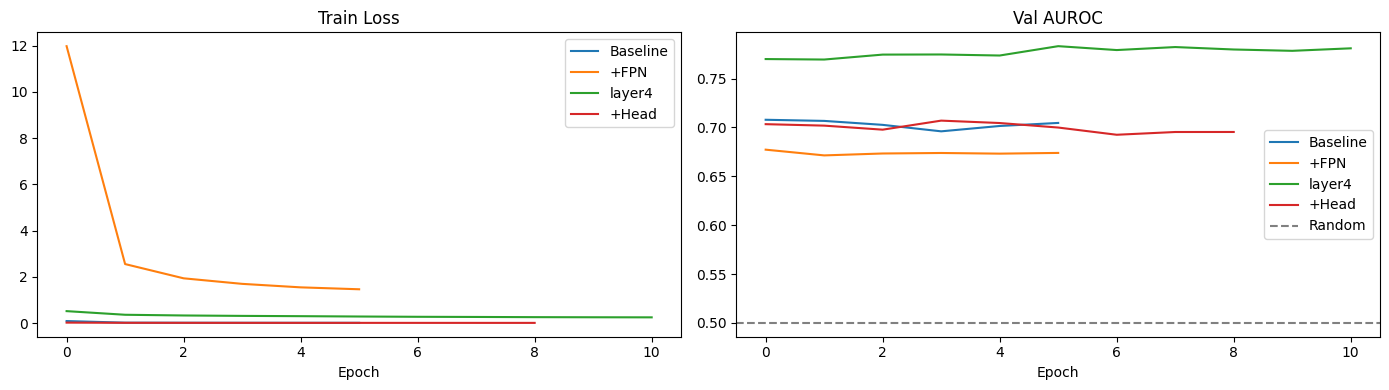

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

for losses, label in [(losses_a, 'Baseline'), (losses_b, '+FPN'), (losses_c, 'layer4'), (losses_d, '+Head')]:
    axes[0].plot(losses, label=label)
axes[0].set_title('Train Loss')
axes[0].set_xlabel('Epoch')
axes[0].legend()

for aurocs, label in [(aurocs_a, 'Baseline'), (aurocs_b, '+FPN'), (aurocs_c, 'layer4'), (aurocs_d, '+Head')]:
    axes[1].plot(aurocs, label=label)
axes[1].axhline(0.5, color='gray', linestyle='--', label='Random')
axes[1].set_title('Val AUROC')
axes[1].set_xlabel('Epoch')
axes[1].legend()

plt.tight_layout()
plt.savefig('results/st_training_curves.png', dpi=150)
plt.show()

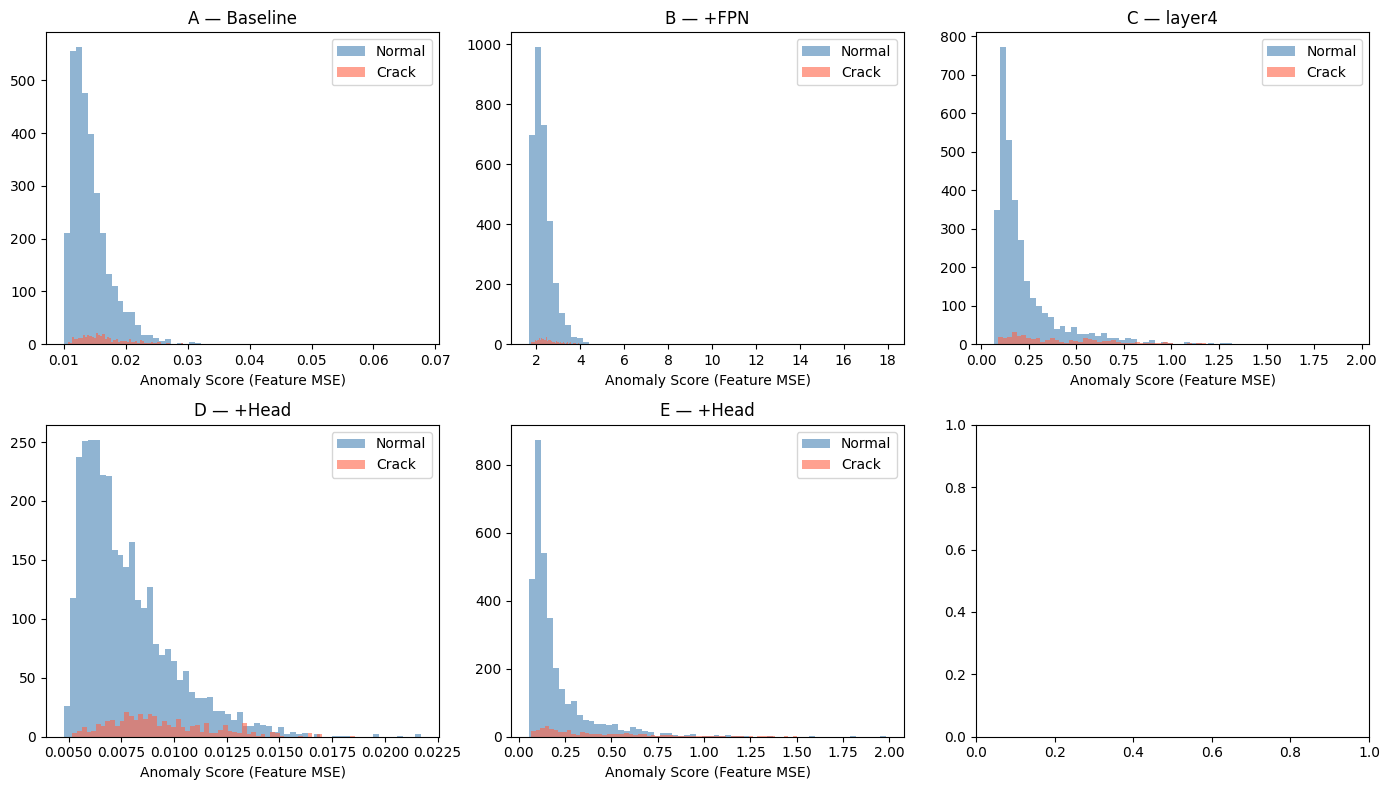

In [22]:
fig, axes = plt.subplots(2, 3, figsize=(14, 8))
for ax, (name, scores) in zip(axes.flat, [
    ('A — Baseline', scores_a), ('B — +FPN', scores_b),
    ('C — layer4',   scores_c), ('D — +Head', scores_d), ('E — +Head', scores_e)
]):
    ax.hist(scores[test_labels == 0], bins=60, alpha=0.6, label='Normal', color='steelblue')
    ax.hist(scores[test_labels == 1], bins=60, alpha=0.6, label='Crack',  color='tomato')
    ax.set_title(name)
    ax.set_xlabel('Anomaly Score (Feature MSE)')
    ax.legend()
plt.tight_layout()
plt.savefig('results/st_score_histograms.png', dpi=150)
plt.show()

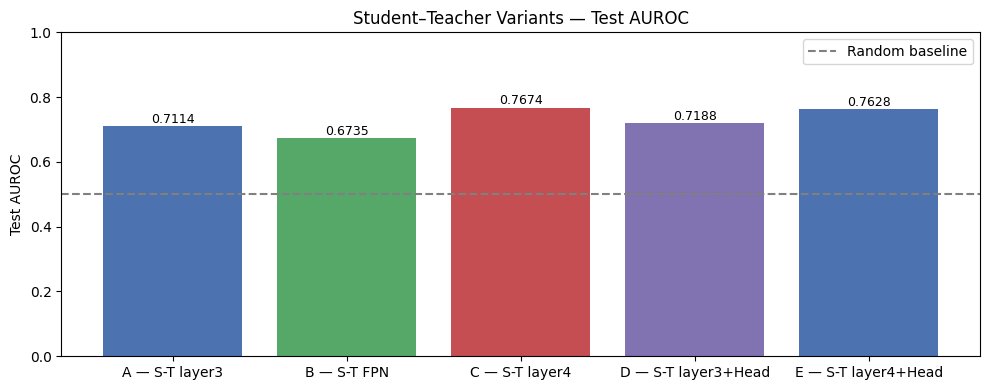

In [23]:
names  = list(results.keys())
aurocs = [results[n]['auroc'] for n in names]

fig, ax = plt.subplots(figsize=(10, 4))
bars = ax.bar(names, aurocs, color=['#4C72B0', '#55A868', '#C44E52', '#8172B2'])
ax.axhline(0.5, color='gray', linestyle='--', label='Random baseline')
ax.set_ylim(0, 1)
ax.set_ylabel('Test AUROC')
ax.set_title('Student–Teacher Variants — Test AUROC')
for bar, v in zip(bars, aurocs):
    ax.text(bar.get_x() + bar.get_width()/2, v + 0.01, f'{v:.4f}', ha='center', fontsize=9)
ax.legend()
plt.tight_layout()
plt.savefig('results/st_auroc_comparison.png', dpi=150)
plt.show()

# Results
Student-Teacher anomaly detection worked well on this task because cracks appear as local feature mismatches that a student trained only on normal patches cannot reproduce. Among the five variants, the best result came from Variant C (layer4), which achieved 0.7674 AUROC and 0.2909 AUPRC, with 2654 TN, 606 FP, 176 FN, and 215 TP. This is essentially on par with PatchCore in AUROC (0.7744) while slightly exceeding it in AUPRC, meaning the ranking of anomaly scores is more reliable. Across all variants, the strongest factor was the feature level: layer4 > layer3 > layer2, showing that the deepest features carry the most useful anomaly signal for cracked concrete.

# Issues
The main limitation is that Student-Teacher still behaves as a distance-from-normal method, so it shares a similar ceiling with PatchCore. It is more precise than PatchCore but slightly worse in recall, missing more cracks. Architectural additions such as FPN and projection heads did not improve performance, suggesting that the simple single-scale distillation setup already captures most of what this approach can offer. In practice, Student-Teacher is a strong normal-only baseline, but it does not break beyond the same performance band as PatchCore.

> Since both Patchcore and ST plateau at 0.77, this is possibly the upper most limit for one-class anomaly detection for this dataset. Hence if we want to improve the results, we need to start introducing the negative labels (eg, ProtNet)